# IEM Cologne 2026 — CS2 Major Predictor

End-to-end notebook: **collect CS2-only data → engineer features → train the stacked
ensemble → backtest → simulate the Major** (Stage 1/2/3 Swiss + single-elim playoffs)
and predict the champion.

It drives the reusable `iemcs` package end-to-end and shows the tables and charts inline.

> The first run clones the Valve Regional Standings repo into `data/raw/`
> (set the `VRS_REPO_DIR` env var to reuse an existing clone).

In [1]:
import os, sys

# Find the repo root (the folder containing the `iemcs` package) from any cwd.
_root = os.getcwd()
while not os.path.isdir(os.path.join(_root, "iemcs")) and _root != os.path.dirname(_root):
    _root = os.path.dirname(_root)
sys.path.insert(0, _root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from iemcs import config, vrs, dataset, tournament, validate, report
from iemcs.model import MatchModel
from iemcs.config import FEATURE_COLUMNS
from iemcs.teams import FIELD

# `iemcs.report` forces the Agg backend on import; restore inline afterwards so the
# notebook's own plots render in the cells.
%matplotlib inline
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

N_SIMS = 50_000          # Monte-Carlo runs (the simulation is fast; tune freely)
print("iemcs loaded ·", len(FEATURE_COLUMNS), "engineered features ·", len(FIELD), "teams")

iemcs loaded · 11 engineered features · 32 teams


## 1 · Collect CS2-only data

The single source is Valve's official Regional Standings repo. Its per-team monthly
*details* files are parsed into deduplicated CS2 matches (no CS:GO), plus VRS points,
rosters and regions.

In [2]:
vrs.ensure_repo()
matches   = vrs.parse_matches()
standings = vrs.parse_standings()
region    = vrs.build_region_map()

print(f"{len(matches):,} CS2 matches   {matches.date.min().date()} -> {matches.date.max().date()}")
print(f"{standings.snapshot.nunique()} monthly VRS snapshots · {len(region)} teams with a region")
matches.head()

27,255 CS2 matches   2024-02-08 -> 2026-05-03
42 monthly VRS snapshots · 726 teams with a region


,date,winner,loser
0,2024-02-08,Nemiga,Sashi
1,2024-02-08,FORZE,BetBoom
2,2024-02-08,Insilio,ex-Guild Eagles
3,2024-02-08,AMKAL,RUBY
4,2024-02-09,Falcons,ENCE


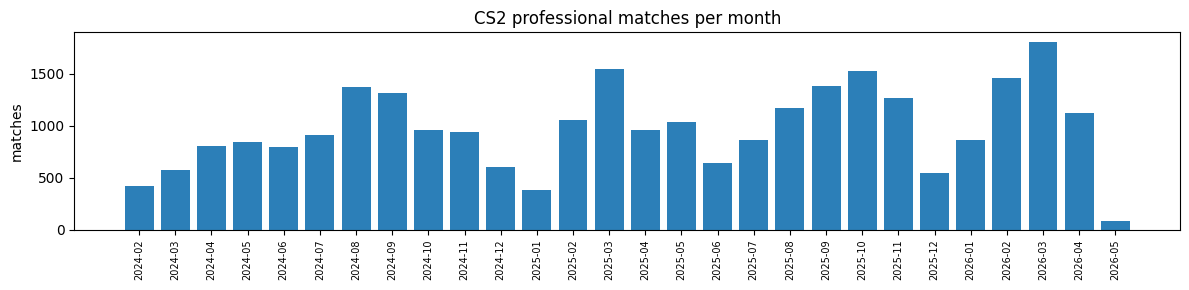

In [3]:
# Match volume over time (the training data)
mc = matches.set_index("date").resample("MS").size()
labels = [d.strftime("%Y-%m") for d in mc.index]
plt.figure(figsize=(12, 3))
plt.bar(range(len(mc)), mc.values, color="#2c7fb8")
plt.xticks(range(len(mc)), labels, rotation=90, fontsize=7)
plt.title("CS2 professional matches per month"); plt.ylabel("matches")
plt.tight_layout(); plt.show()

## 2 · Feature engineering (leak-free)

One chronological pass evolves each team's Elo, Glicko-2, form, streak, activity,
head-to-head and strength-of-schedule, recording *pre-match* features before observing
each result. The fitted `Context` then holds every team's present strength.

In [4]:
frame, ctx = dataset.build(matches, standings, region)
print("feature frame:", frame.shape, "| target balance:", round(frame.y.mean(), 3))
frame[FEATURE_COLUMNS + ["y"]].head()

feature frame: (27255, 19) | target balance: 0.497


,elo_diff,glicko_diff,glicko_rd_sum,vrs_diff,sos_diff,form_diff,h2h_diff,activity_diff,streak_diff,roster_stab_diff,same_region,y
0,0.0,0.0,700.0,0.0,0.0,0.0,0.0,0,0.0,0.0,1.0,0
1,0.0,0.0,700.0,0.0,0.0,0.0,0.0,0,0.0,0.0,1.0,1
2,0.0,0.0,700.0,0.0,0.0,0.0,0.0,0,0.0,0.0,1.0,0
3,0.0,0.0,700.0,0.0,0.0,0.0,0.0,0,0.0,0.0,1.0,0
4,0.0,0.0,700.0,0.0,0.0,0.0,0.0,0,0.0,0.0,1.0,1


In [5]:
# Current strength of the 32-team field
cur  = vrs.current_standings()
cmap = dict(zip(cur.team, cur.points))
now  = matches.date.max()
ladder = pd.DataFrame([
    {"team": t.name, "stage": t.stage,
     "Elo": round(ctx.elo.rating(t.vrs_name)),
     "Glicko": round(ctx.glicko.rating(t.vrs_name)),
     "RD": round(ctx.glicko.rd(t.vrs_name)),
     "VRS": cmap.get(t.vrs_name, 1000)}
    for t in FIELD
]).sort_values("Elo", ascending=False).reset_index(drop=True)
ladder.head(12)

,team,stage,Elo,Glicko,RD,VRS
0,Vitality,3,2207,2246,67,2081
1,Falcons,3,2020,2056,62,1823
2,Spirit,2,2001,2069,65,1807
3,Natus Vincere,3,1994,2028,62,1885
4,9z,2,1939,1919,66,1508
5,FUT,2,1925,1948,62,1808
6,The MongolZ,3,1921,1981,63,1791
7,FURIA,3,1919,1991,63,1730
8,Astralis,2,1907,1935,61,1800
9,PARIVISION,3,1902,1957,62,1747


## 3 · Train the stacked ensemble

Base learners (logistic regression, random forest, hist-gradient-boosting) + the Elo /
Glicko-2 / VRS expectations are combined by a logistic meta-learner on out-of-fold
predictions, isotonically calibrated, with a cross-region VRS blend tuned on held-out
cross-region matches.

In [6]:
from iemcs.torch_model import _HAS_TORCH
model = MatchModel().fit(frame, verbose=True)
print("PyTorch MLP active:", _HAS_TORCH, "| base learners:", list(model.base))
pd.DataFrame({"member": model.stack_columns,
              "meta_weight": model.meta.coef_[0].round(3)})

  base learners: ['logreg', 'rf', 'gbm', 'knn', 'mlp']
  meta coefs   : elo_p=-0.14, glicko_p=+0.18, vrs_p=-0.17, logreg=+0.69, rf=+1.73, gbm=+0.60, knn=+1.31, mlp=+0.74
  OOF log-loss : stack=0.6140 calibrated=0.6119
  cross-region VRS blend w=0.35 (n_xr=1591); xr log-loss 0.6402 -> 0.6294
PyTorch MLP active: True | base learners: ['logreg', 'rf', 'gbm', 'knn', 'mlp']


,member,meta_weight
0,elo_p,-0.137
1,glicko_p,0.179
2,vrs_p,-0.165
3,logreg,0.689
4,rf,1.725
5,gbm,0.604
6,knn,1.308
7,mlp,0.741


## 4 · Backtest & feature importance

Walk-forward (train on the past, predict the next block) vs rating-only baselines, plus
the out-of-sample calibration curve and permutation feature importance.

In [7]:
bt = validate.backtest(frame, n_splits=3)
validate.print_report(bt)
pd.DataFrame({k: bt[k] for k in ["ensemble", "elo_only", "vrs_only"]}).T[
    ["accuracy", "log_loss", "brier", "auc", "n"]].round(4)

  fold 1: train=6816 test=6813 blend_w=0.00


  fold 2: train=13629 test=6813 blend_w=0.40


  fold 3: train=20442 test=6813 blend_w=0.30

=== Walk-forward backtest (out-of-sample) ===
model                          n     acc   logloss   brier     auc
------------------------------------------------------------------
ensemble                   20439   0.658    0.6288  0.2153   0.715
elo_only                   20439   0.639    0.6312  0.2208   0.694
vrs_only                   20439   0.571    0.7249  0.2577   0.597
ensemble_cross_region       2862   0.666    0.6052  0.2096   0.729
elo_cross_region            2862   0.623    0.6346  0.2229   0.680

ensemble beats Elo-only on log-loss by +0.0025 (PASS)


,accuracy,log_loss,brier,auc,n
ensemble,0.6575,0.6288,0.2153,0.7149,20439.0
elo_only,0.6391,0.6312,0.2208,0.6943,20439.0
vrs_only,0.5707,0.7249,0.2577,0.5971,20439.0


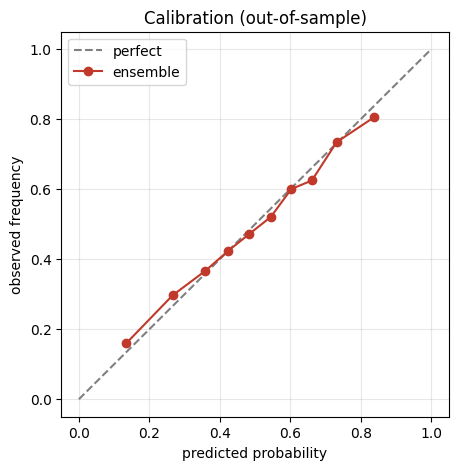

In [8]:
from sklearn.calibration import calibration_curve
y, p = bt["_reliability"]
frac, mean_pred = calibration_curve(y, p, n_bins=10, strategy="quantile")
plt.figure(figsize=(5, 5))
plt.plot([0, 1], [0, 1], "--", color="gray", label="perfect")
plt.plot(mean_pred, frac, "o-", color="#c0392b", label="ensemble")
plt.xlabel("predicted probability"); plt.ylabel("observed frequency")
plt.title("Calibration (out-of-sample)"); plt.legend(); plt.grid(alpha=.3); plt.show()

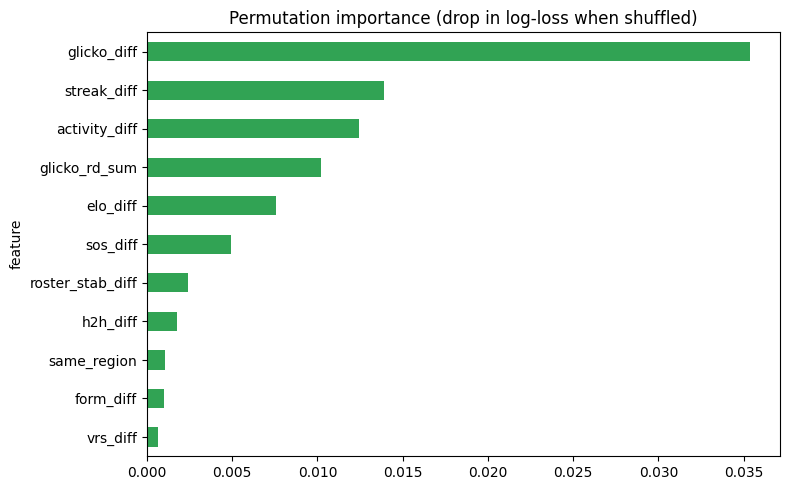

,feature,uni_AUC_gap,perm_importance
0,glicko_diff,0.2016,0.0354
1,streak_diff,0.0822,0.0139
2,activity_diff,0.1054,0.0124
3,glicko_rd_sum,0.0100,0.0102
4,elo_diff,0.1945,0.0076
5,sos_diff,0.0999,0.0049
6,roster_stab_diff,0.0586,0.0024
7,h2h_diff,0.0747,0.0017
8,same_region,0.0009,0.0011
9,form_diff,0.1197,0.0010


In [9]:
# Permutation importance + standalone AUC for each feature
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score

k = int(len(frame) * 0.8)
tr, te = frame.iloc[:k], frame.iloc[k:]
gbm = HistGradientBoostingClassifier(max_iter=400, learning_rate=0.05, max_depth=4,
                                     l2_regularization=1.0, random_state=0)
gbm.fit(tr[FEATURE_COLUMNS], tr.y)
pi = permutation_importance(gbm, te[FEATURE_COLUMNS], te.y,
                            scoring="neg_log_loss", n_repeats=8, random_state=0)
imp = pd.DataFrame({
    "feature": FEATURE_COLUMNS,
    "uni_AUC_gap": [abs(roc_auc_score(te.y, te[f]) - 0.5) for f in FEATURE_COLUMNS],
    "perm_importance": pi.importances_mean,
}).sort_values("perm_importance", ascending=False).reset_index(drop=True)

ax = imp.set_index("feature")["perm_importance"].iloc[::-1].plot.barh(
    figsize=(8, 5), color="#31a354")
ax.set_title("Permutation importance (drop in log-loss when shuffled)")
plt.tight_layout(); plt.show()
imp.round(4)

## 4b · Model comparison — pre vs post ensemble

Out-of-sample (time-held-out last 20%) metrics for **each base learner on its own**, the
rating signals for reference, and the stacked ensemble **without** vs **with** the new
KNN member. Lower `log_loss`/`brier` and higher `auc`/`accuracy` are better.

The KNN member adds instance-based diversity; the `ENSEMBLE (no knn)` vs `ENSEMBLE
(full)` rows isolate its effect. Note that stacking buys *robust, calibrated*
probabilities rather than a guaranteed log-loss win on every split — on a single recent
window the strongest single model can edge it, and the cross-region VRS blend trades a
little raw log-loss for sanity in the *simulation* (it stops weak-region teams being
over-rated in the cross-region matchups that dominate a Major).

In [10]:
comp = validate.compare_models(frame, new_member="knn")
comp.round(4)

,accuracy,log_loss,brier,auc,n
mlp,0.6623,0.6109,0.2119,0.7240,5451.0
gbm,0.6564,0.6144,0.2133,0.7200,5451.0
rf,0.6520,0.6153,0.2139,0.7172,5451.0
logreg,0.6514,0.6204,0.2162,0.7093,5451.0
knn,0.6557,0.6219,0.2146,0.7162,5451.0
ENSEMBLE (full),0.6538,0.6244,0.2167,0.7121,5451.0
ENSEMBLE (no knn),0.6502,0.6247,0.2169,0.7111,5451.0
elo_p,0.6347,0.6296,0.2203,0.6947,5451.0
vrs_p,0.5825,0.7119,0.2524,0.6180,5451.0


## 4c · End-to-end simulator backtest (real Majors)

The match-level backtest above tests single predictions; this tests the **whole stack**
(ratings → ensemble → series math → bracket) against reality. It replays the actual
8-team playoff brackets of the last two CS2 Majors using a model trained **only on
pre-event data**, and compares predicted reach-SF / reach-final / champion
probabilities to what really happened. (Both were won by Vitality, so the discriminating
signal is the reach-SF / reach-final Brier — did it rank the right four / two teams?)

In [11]:
from iemcs import simbacktest

sim_bt = simbacktest.run(matches, standings, region, recency_half_life=365, n_sims=20000)
print("End-to-end metrics:", {k: round(v, 4) for k, v in simbacktest.metrics(sim_bt).items()})

majors = list(sim_bt["major"].unique())
for mj in majors:                                    # one table per Major
    print(f"\n=== {mj} ===")
    display(sim_bt[sim_bt.major == mj].drop(columns="major")
            .sort_values("P_champion", ascending=False)
            .reset_index(drop=True).round(3))

End-to-end metrics: {'brier_champion': 0.0754, 'brier_reach_final': 0.1471, 'brier_reach_SF': 0.2485, 'actual_champion_mean_prob': 0.3368, 'n_teams': 16}

=== BLAST Austin 2025 ===


,team,P_reach_SF,P_reach_final,P_champion,actual
0,Vitality,0.800,0.491,0.432,Champion
1,Spirit,0.625,0.330,0.261,QF
2,The MongolZ,0.610,0.432,0.115,Final
3,MOUZ,0.375,0.120,0.081,SF
4,FaZe,0.390,0.231,0.036,QF
5,FURIA,0.674,0.254,0.036,QF
6,Natus Vincere,0.200,0.058,0.032,QF
7,paiN,0.326,0.084,0.006,SF



=== StarLadder Budapest 2025 ===


,team,P_reach_SF,P_reach_final,P_champion,actual
0,FURIA,0.776,0.627,0.441,QF
1,Vitality,0.695,0.454,0.242,Champion
2,Spirit,0.571,0.234,0.102,SF
3,Falcons,0.429,0.185,0.077,QF
4,Natus Vincere,0.224,0.151,0.048,SF
5,The MongolZ,0.305,0.127,0.043,QF
6,FaZe,0.733,0.165,0.040,Final
7,MOUZ,0.267,0.057,0.008,QF


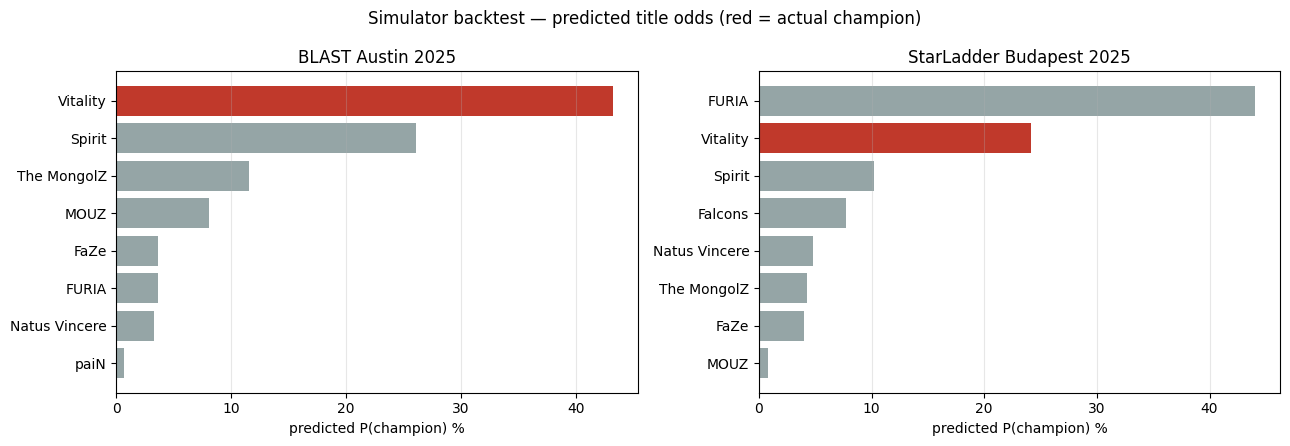

In [12]:
# Predicted title odds per Major (red = the team that actually won)
fig, axes = plt.subplots(1, len(majors), figsize=(13, 4.5))
for ax, mj in zip(axes, majors):
    d = sim_bt[sim_bt.major == mj].sort_values("P_champion")
    colors = ["#c0392b" if a == "Champion" else "#95a5a6" for a in d["actual"]]
    ax.barh(d["team"], d["P_champion"] * 100, color=colors)
    ax.set_title(mj); ax.set_xlabel("predicted P(champion) %"); ax.grid(axis="x", alpha=.3)
fig.suptitle("Simulator backtest — predicted title odds (red = actual champion)")
fig.tight_layout(); plt.show()

## 5 · Simulate the Major

Build the per-map win-probability table for all 32 teams, then Monte-Carlo the full
format (three Swiss stages + single-elim playoffs) `N_SIMS` times.

In [13]:
vrs_pts = {t.name: float(cmap.get(t.vrs_name, 1000)) for t in FIELD}
pmap = tournament.build_pmap(model, ctx, now)
res  = tournament.run_monte_carlo(pmap, vrs_pts, n_sims=N_SIMS, n_jobs=-1)

assert abs(res.champion.sum() - 1) < 1e-6 and abs(res.adv_s3.sum() - 8) < 1e-6
disp = res[["stage", "vrs", "adv_s1", "adv_s2", "adv_s3",
            "semifinal", "final", "champion"]].copy()
for c in ["adv_s1", "adv_s2", "adv_s3", "semifinal", "final", "champion"]:
    disp[c] = (disp[c] * 100).round(1)
disp

,stage,vrs,adv_s1,adv_s2,adv_s3,semifinal,final,champion
team,,,,,,,,
Vitality,3,2081.0,NaN,NaN,97.8,82.6,69.8,62.2
Falcons,3,1823.0,NaN,NaN,78.2,44.1,22.2,7.8
Natus Vincere,3,1885.0,NaN,NaN,76.0,42.2,20.7,7.2
Spirit,2,1807.0,NaN,80.4,52.9,28.4,13.1,4.2
The MongolZ,3,1791.0,NaN,NaN,65.5,31.9,13.7,4.0
FURIA,3,1730.0,NaN,NaN,65.3,31.7,13.5,3.9
PARIVISION,3,1747.0,NaN,NaN,57.0,24.6,9.4,2.4
Aurora,3,1742.0,NaN,NaN,56.8,25.0,9.2,2.3
Astralis,2,1800.0,NaN,70.1,33.8,14.3,5.3,1.3


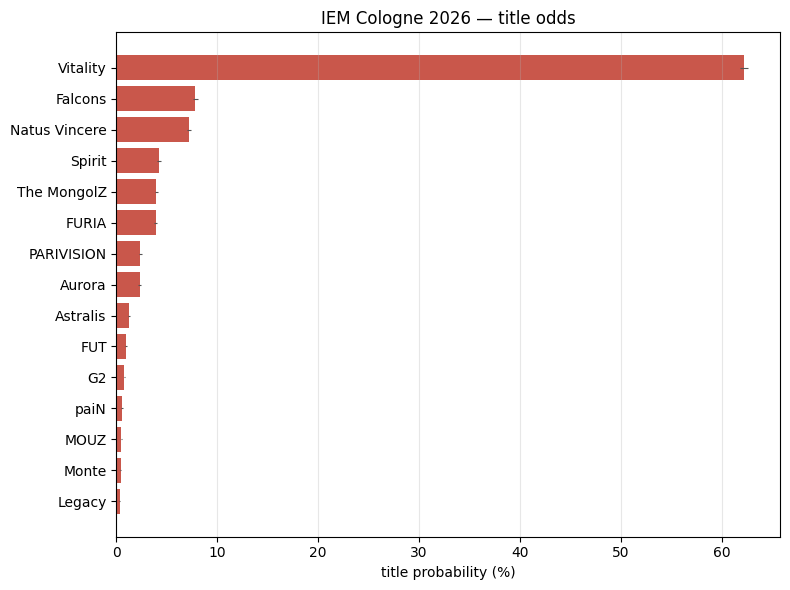

In [14]:
# Title odds with Monte-Carlo confidence intervals
top = res.sort_values("champion").tail(15)
plt.figure(figsize=(8, 6))
plt.barh(top.index, top.champion * 100,
         xerr=[(top.champion - top.champion_lo) * 100,
               (top.champion_hi - top.champion) * 100],
         color="#c0392b", alpha=.85, error_kw=dict(ecolor="#555", lw=.8))
plt.xlabel("title probability (%)"); plt.title("IEM Cologne 2026 — title odds")
plt.grid(axis="x", alpha=.3); plt.tight_layout(); plt.show()

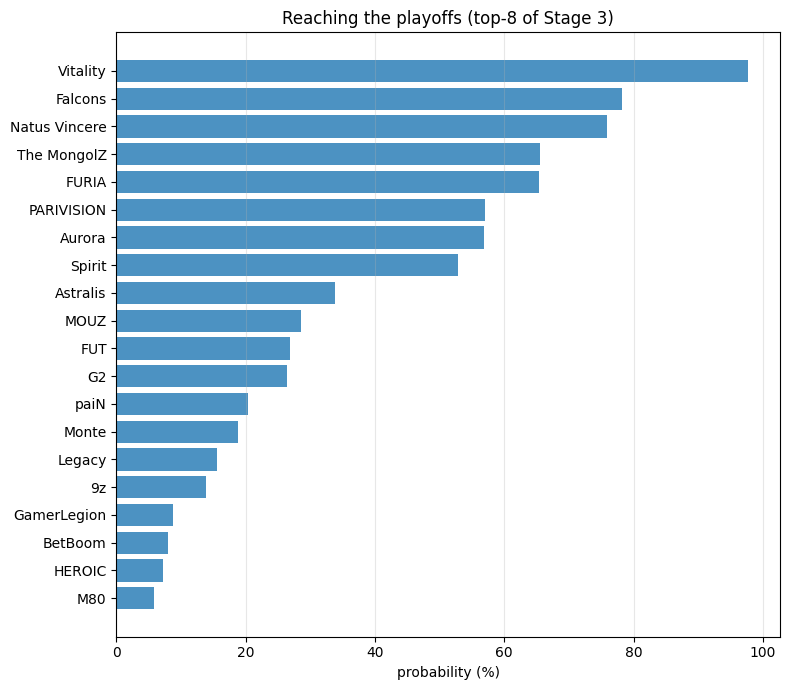

In [15]:
# Probability of reaching the playoffs (Stage 3 top-8)
po = res.sort_values("adv_s3").tail(20)
plt.figure(figsize=(8, 7))
plt.barh(po.index, po.adv_s3 * 100, color="#2c7fb8", alpha=.85)
plt.xlabel("probability (%)"); plt.title("Reaching the playoffs (top-8 of Stage 3)")
plt.grid(axis="x", alpha=.3); plt.tight_layout(); plt.show()

In [16]:
# Persist the full set of artifacts (CSVs, charts, markdown report)
bt_clean = {k: v for k, v in bt.items() if k != "_reliability"}
csvs   = report.save_csvs(res)
charts = report.charts(res)
md_out = report.write_markdown(res, bt_clean)
print(f"Saved {len(csvs)} CSVs and {len(charts)} charts to {config.OUTPUTS_DIR}")
print("Report:", md_out)

Saved 5 CSVs and 4 charts to /mnt/c/Users/sharp/Documents/GitHub/iemcologne2026/outputs
Report: /mnt/c/Users/sharp/Documents/GitHub/iemcologne2026/outputs/REPORT.md


## 6 · Stage 1 Pick'Em — optimised for P(≥5 correct)

The Round-1 matchups (from `data/r1matchup.jpeg`, which match the standard VRS seeding)
are simulated 40,000 times to get each team's advance / 3-0 / 0-3 probability. The
Pick'Em asks for **2 teams 3-0, 6 to advance, 2 teams 0-3**, and you must get **≥5 of
10** correct. Because the picks are correlated and the win condition is a threshold, we
**maximise P(≥5 correct)** rather than the expected number — searching pick-sets over
the simulated brackets.

In [17]:
from iemcs import pickem

vrs_pts = dict(zip(pd.read_csv(config.TEAMS_CSV)["team"],
                   pd.read_csv(config.TEAMS_CSV)["vrs_points"]))
teams_s1, M3, MA, M03 = pickem.simulate_stage1(
    model, ctx, vrs_pts, matches["date"].max(), n_sims=40000)
pickem.probabilities(teams_s1, M3, MA, M03).round(3)

,team,P_advance,P_3_0,P_0_3
0,GamerLegion,0.656,0.191,0.068
1,BetBoom,0.642,0.194,0.071
2,HEROIC,0.625,0.178,0.076
3,M80,0.585,0.147,0.087
4,B8,0.584,0.161,0.084
5,BIG,0.563,0.154,0.088
6,SINNERS,0.549,0.147,0.092
7,Lynn Vision,0.517,0.119,0.119
8,NRG,0.509,0.114,0.117
9,THUNDERdOWNUNDER,0.508,0.120,0.116


In [18]:
opt = pickem.optimize(teams_s1, M3, MA, M03, threshold=5)
print(f"Naive  (most-likely per slot) : P(>=5) = {opt['naive']['p']:.3f}")
print(f"OPTIMAL (max P>=5)            : P(>=5) = {opt['optimal']['p']:.3f}")
print("curve :", {k: round(v, 3) for k, v in opt['curve'].items()})
o = opt['optimal']['picks']
print("\nRECOMMENDED PICK'EM")
print("  3-0     :", o['3-0'])
print("  advance :", o['advance'])
print("  0-3     :", o['0-3'])

Naive  (most-likely per slot) : P(>=5) = 0.429
OPTIMAL (max P>=5)            : P(>=5) = 0.471
curve : {'P>=4': 0.758, 'P>=5': 0.471, 'P>=6': 0.194}

RECOMMENDED PICK'EM
  3-0     : ['SINNERS', 'THUNDERdOWNUNDER']
  advance : ['GamerLegion', 'BetBoom', 'HEROIC', 'M80', 'B8', 'BIG']
  0-3     : ['FlyQuest', 'Gaimin Gladiators']


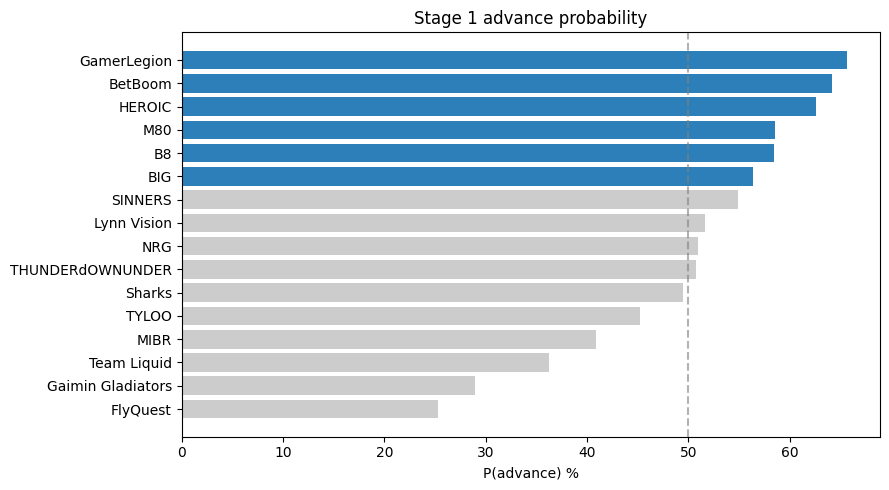

In [19]:
# Advance probabilities — blue = the 6 recommended 'advance' picks
prob = pickem.probabilities(teams_s1, M3, MA, M03)
picks = set(opt['optimal']['picks']['advance'])
colors = ['#2c7fb8' if t in picks else '#cccccc' for t in prob['team']]
plt.figure(figsize=(9, 5))
plt.barh(prob['team'][::-1], (prob['P_advance'] * 100)[::-1], color=colors[::-1])
plt.axvline(50, ls='--', c='gray', alpha=.6)
plt.xlabel('P(advance) %'); plt.title('Stage 1 advance probability')
plt.tight_layout(); plt.show()

## Notes

- **Vitality** emerge as a heavy favourite because they were dominant across the
  2024–2026 CS2 data the model trains on — it reflects the data, not a hand-set prior.
  Raise `PROB_SHRINK` in `iemcs/config.py` to add upset variance.
- Re-running top-to-bottom closer to the event folds in the latest VRS update and rosters.
- All logic lives in the reusable `iemcs` package; this notebook is the single entry point.